# Catastrophe Bond Pricing Analysis

This notebook analyses tranche-level catastrophe bond pricing data collected from Artemis. The dependent variable is `spread_pct`. The main explanatory variable is `expected_loss_pct`, with additional controls for trigger type, peril type, and issuance year.

## Cell 1 — Import packages
Run this first. It loads the packages used for cleaning, EDA, visualisation, and regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Cell 2 — Load the Artemis dataset
This cell tries common file locations. Keep the Excel file in the same folder as the notebook, or adjust `DATA_FILE`.

In [2]:
# The main dataset is stored in the Data sheet.
df = pd.read_excel("artemis_cat_bond_tranche_dataset_extended.xlsx")


df.head()

,deal_name,issuer,sponsor,issue_year,issue_month,tranche_class,peril_type,trigger_type,coverage_basis,tranche_size_m,expected_loss_pct,spread_pct,spread_basis,source_url,validation_status,notes,regression_ready,spread_to_el_multiple
0,Alamo Re Ltd. (Series 2014-1),Alamo Re Ltd.,Texas Windstorm Insurance Association (TWIA),2014,Jun,Class A,Texas named storms,Indemnity,Annual aggregate,400.000,2.840,6.350,Final spread,https://www.artemis.bm/deal-directory/alamo-re...,Checked against Artemis page/text,Artemis page gives EL 2.84%; final coupon/spre...,Yes,2.236
1,Citrus Re Ltd. (Series 2014-1),Citrus Re Ltd.,Heritage Property and Casualty Insurance Co.,2014,Apr,Class A,U.S. named storms (Florida initially),Indemnity,Per-occurrence,150.000,1.280,4.250,Final spread,https://www.artemis.bm/deal-directory/citrus-r...,Checked against Artemis page/text,Artemis page gives EL 1.28%; final coupon 4.25%.,Yes,3.320
2,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 1-B,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,100.000,2.200,6.750,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,3.068
3,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 3-A,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,100.000,1.140,5.000,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,4.386
4,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 3-B,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,300.000,2.200,7.000,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,3.182


## Cell 3 — Clean column names and inspect structure
This standardises names and removes fully empty columns if Excel imported any.

In [3]:
df = df.dropna(axis=1, how="all")

print(f"Cleaned shape: {df.shape}")
print(df.columns.tolist())
df.info()

Cleaned shape: (157, 18)
['deal_name', 'issuer', 'sponsor', 'issue_year', 'issue_month', 'tranche_class', 'peril_type', 'trigger_type', 'coverage_basis', 'tranche_size_m', 'expected_loss_pct', 'spread_pct', 'spread_basis', 'source_url', 'validation_status', 'notes', 'regression_ready', 'spread_to_el_multiple']
<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   deal_name              157 non-null    str    
 1   issuer                 157 non-null    str    
 2   sponsor                157 non-null    str    
 3   issue_year             157 non-null    int64  
 4   issue_month            156 non-null    str    
 5   tranche_class          157 non-null    str    
 6   peril_type             157 non-null    str    
 7   trigger_type           157 non-null    str    
 8   coverage_basis         157 non-null    str    
 9   tranche_size_m   

## Cell 4 — Convert variables to correct types
The regression needs numeric `spread_pct`, `expected_loss_pct`, and `issue_year`. Categorical variables are converted to strings/categories.

In [4]:
numeric_cols = ["issue_year", "tranche_size_m", "expected_loss_pct", "spread_pct", "spread_to_el_multiple"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

text_cols = [
    "deal_name", "issuer", "sponsor", "tranche_class", "peril_type",
    "trigger_type", "coverage_basis", "spread_basis", "validation_status",
    "regression_ready", "source_url", "notes"
]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Standardise yes/no field.
if "regression_ready" in df.columns:
    df["regression_ready"] = df["regression_ready"].str.title()

# Recalculate spread-to-expected-loss multiple to avoid relying on Excel formulas.
df["spread_to_el_multiple_calc"] = np.where(
    df["expected_loss_pct"] > 0,
    df["spread_pct"] / df["expected_loss_pct"],
    np.nan
)

df[["issue_year", "expected_loss_pct", "spread_pct", "trigger_type", "peril_type", "regression_ready"]].head()

,issue_year,expected_loss_pct,spread_pct,trigger_type,peril_type,regression_ready
0,2014,2.840,6.350,Indemnity,Texas named storms,Yes
1,2014,1.280,4.250,Indemnity,U.S. named storms (Florida initially),Yes
2,2014,2.200,6.750,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes
3,2014,1.140,5.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes
4,2014,2.200,7.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes


## Cell 5 — Basic data quality checks
This checks sample size, missing values, and duplicated tranche identifiers.

In [5]:
quality_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Regression-ready rows",
        "Rows with spread",
        "Rows with expected loss",
        "Rows with both spread and expected loss",
        "Earliest issue year",
        "Latest issue year",
        "Unique deals",
        "Unique sponsors"
    ],
    "value": [
        len(df),
        (df["regression_ready"] == "Yes").sum() if "regression_ready" in df.columns else np.nan,
        df["spread_pct"].notna().sum(),
        df["expected_loss_pct"].notna().sum(),
        df[["spread_pct", "expected_loss_pct"]].dropna().shape[0],
        int(df["issue_year"].min()),
        int(df["issue_year"].max()),
        df["deal_name"].nunique(),
        df["sponsor"].nunique() if "sponsor" in df.columns else np.nan
    ]
})

quality_summary

,metric,value
0,Total rows,157
1,Regression-ready rows,153
2,Rows with spread,157
3,Rows with expected loss,153
4,Rows with both spread and expected loss,153
5,Earliest issue year,2014
6,Latest issue year,2026
7,Unique deals,84
8,Unique sponsors,59


## Cell 6 — Missing values table
This helps you transparently report the quality of the dataset.

In [6]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
      .sort_values("missing_pct", ascending=False)
)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
notes,85,54.140
tranche_size_m,29,18.471
expected_loss_pct,4,2.548
spread_to_el_multiple,4,2.548
spread_to_el_multiple_calc,4,2.548
issue_month,1,0.637


## Cell 7 — Create the regression sample
For the main empirical analysis, use only rows marked as regression-ready with non-missing spread and expected loss.

In [7]:
reg = df.copy()

if "regression_ready" in reg.columns:
    reg = reg[reg["regression_ready"] == "Yes"].copy()

reg = reg.dropna(subset=["spread_pct", "expected_loss_pct", "issue_year", "trigger_type", "peril_type"]).copy()

# Keep economically valid rows.
reg = reg[(reg["spread_pct"] > 0) & (reg["expected_loss_pct"] > 0)].copy()

print(f"Regression sample size: {len(reg)}")
reg[["deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct", "trigger_type", "peril_type"]].head()

Regression sample size: 153


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,trigger_type,peril_type
0,Alamo Re Ltd. (Series 2014-1),Class A,2014,2.840,6.350,Indemnity,Texas named storms
1,Citrus Re Ltd. (Series 2014-1),Class A,2014,1.280,4.250,Indemnity,U.S. named storms (Florida initially)
2,Tradewynd Re Ltd. (Series 2014-1),Class 1-B,2014,2.200,6.750,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."
3,Tradewynd Re Ltd. (Series 2014-1),Class 3-A,2014,1.140,5.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."
4,Tradewynd Re Ltd. (Series 2014-1),Class 3-B,2014,2.200,7.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."


## Cell 8 — Create broader peril categories
The raw `peril_type` field can be very detailed. For regression, broader categories avoid too many sparse dummy variables.

In [8]:
def classify_peril(text):
    text = str(text).lower()
    if any(word in text for word in ["multi", "multiple", "named storm and earthquake", "storm and earthquake"]):
        return "Multi-peril"
    if any(word in text for word in ["hurricane", "named storm", "wind", "typhoon", "cyclone"]):
        return "Wind/Storm"
    if "earthquake" in text or "quake" in text:
        return "Earthquake"
    if "wildfire" in text or "fire" in text:
        return "Wildfire"
    if "flood" in text:
        return "Flood"
    if "mortality" in text or "pandemic" in text:
        return "Mortality/Pandemic"
    return "Other"

reg["broad_peril"] = reg["peril_type"].apply(classify_peril).astype("category")
reg["trigger_type"] = reg["trigger_type"].astype("category")
reg["issue_year_cat"] = reg["issue_year"].astype(int).astype("category")

reg[["peril_type", "broad_peril", "trigger_type"]].head(10)

,peril_type,broad_peril,trigger_type
0,Texas named storms,Wind/Storm,Indemnity
1,U.S. named storms (Florida initially),Wind/Storm,Indemnity
2,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
3,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
4,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
5,California earthquake,Earthquake,Indemnity
6,California earthquake,Earthquake,Indemnity
7,Turkey earthquake,Earthquake,Parametric
8,Florida named storms,Wind/Storm,Indemnity
9,Japan earthquake,Earthquake,Indemnity


# Exploratory Data Analysis

## Cell 9 — Descriptive statistics for main numeric variables

In [9]:
main_numeric = ["spread_pct", "expected_loss_pct", "spread_to_el_multiple_calc", "tranche_size_m", "issue_year"]
reg[main_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
spread_pct,153.000,7.202,3.544,1.875,4.500,6.500,9.250,20.000
expected_loss_pct,153.000,2.840,1.998,0.115,1.290,2.200,4.030,9.720
spread_to_el_multiple_calc,153.000,3.623,4.099,1.066,1.997,2.551,3.893,42.308
tranche_size_m,125.000,152.412,110.577,25.000,75.000,125.000,200.000,500.000
issue_year,153.000,"2,021.967",4.165,"2,014.000","2,017.000","2,024.000","2,026.000","2,026.000"


## Cell 10 — Sample composition by issuance year
This shows whether your sample is balanced across time.

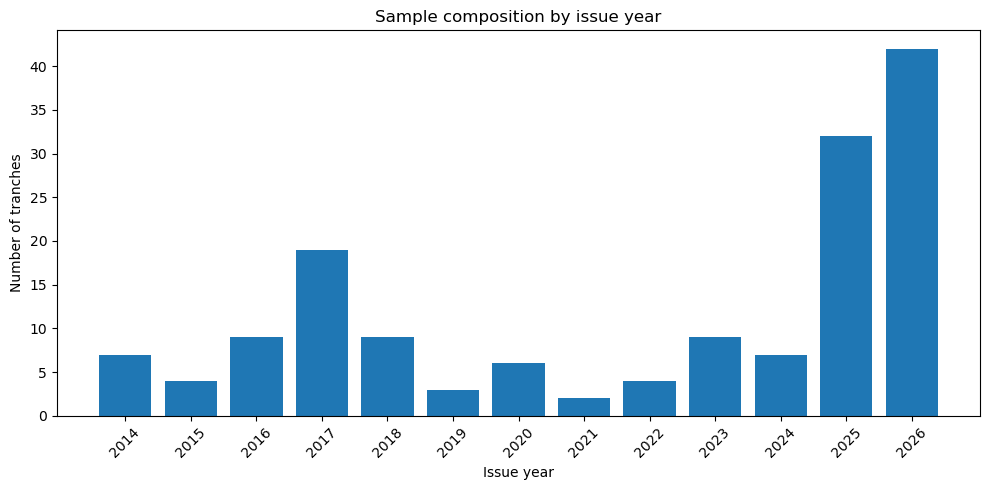

,n_tranches
issue_year,
2014,7
2015,4
2016,9
2017,19
2018,9
2019,3
2020,6
2021,2
2022,4


In [10]:
year_counts = reg["issue_year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xlabel("Issue year")
plt.ylabel("Number of tranches")
plt.title("Sample composition by issue year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_counts.to_frame("n_tranches")

## Cell 11 — Sample composition by trigger type

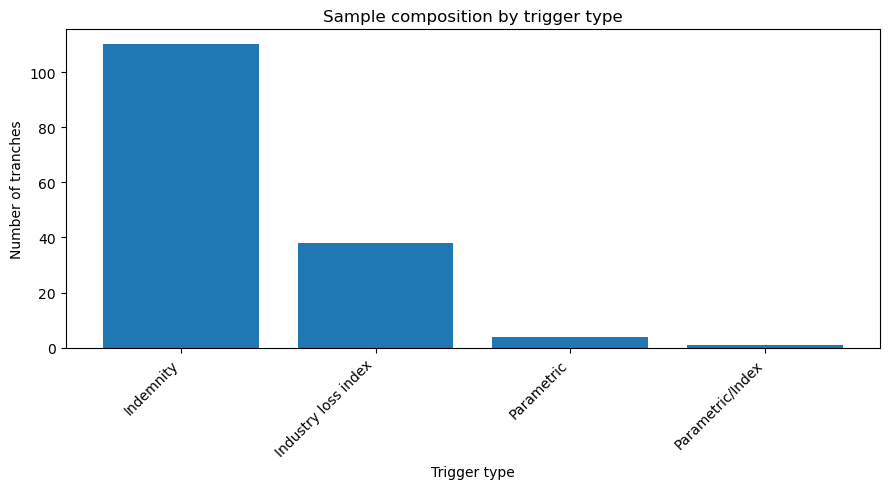

,n_tranches
trigger_type,
Indemnity,110
Industry loss index,38
Parametric,4
Parametric/Index,1


In [11]:
trigger_counts = reg["trigger_type"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(trigger_counts.index.astype(str), trigger_counts.values)
plt.xlabel("Trigger type")
plt.ylabel("Number of tranches")
plt.title("Sample composition by trigger type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

trigger_counts.to_frame("n_tranches")

## Cell 12 — Sample composition by broad peril category

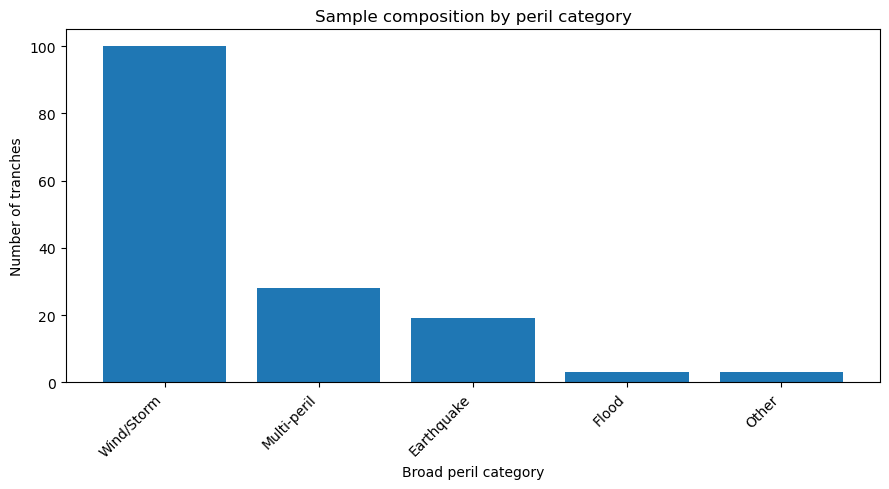

,n_tranches
broad_peril,
Wind/Storm,100
Multi-peril,28
Earthquake,19
Flood,3
Other,3


In [12]:
peril_counts = reg["broad_peril"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(peril_counts.index.astype(str), peril_counts.values)
plt.xlabel("Broad peril category")
plt.ylabel("Number of tranches")
plt.title("Sample composition by peril category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

peril_counts.to_frame("n_tranches")

## Cell 13 — Distribution of expected loss

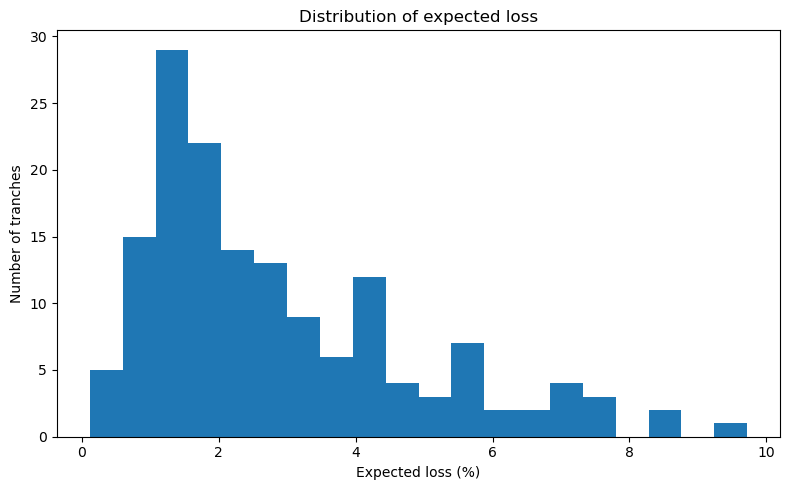

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(reg["expected_loss_pct"].dropna(), bins=20)
plt.xlabel("Expected loss (%)")
plt.ylabel("Number of tranches")
plt.title("Distribution of expected loss")
plt.tight_layout()
plt.show()

## Cell 14 — Distribution of spread

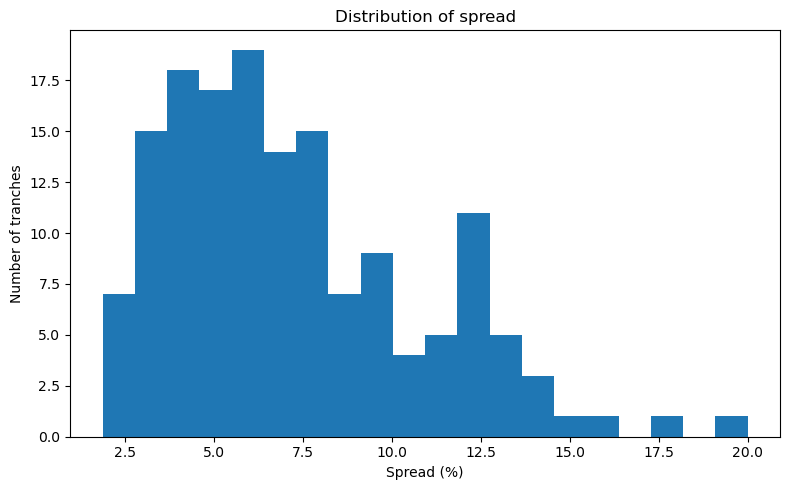

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(reg["spread_pct"].dropna(), bins=20)
plt.xlabel("Spread (%)")
plt.ylabel("Number of tranches")
plt.title("Distribution of spread")
plt.tight_layout()
plt.show()

## Cell 15 — Spread versus expected loss
This is the key relationship behind H1.

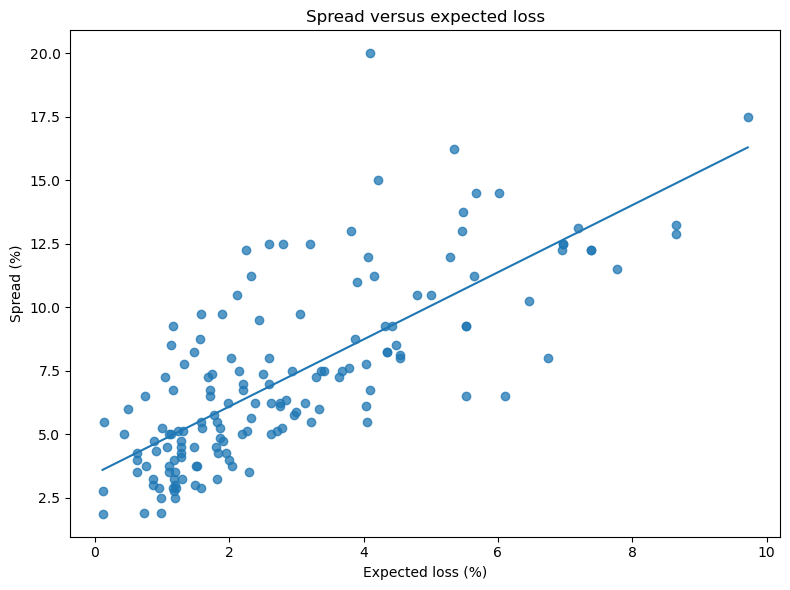

Visual fitted line: spread = 3.448 + 1.322 * expected_loss


In [15]:
x = reg["expected_loss_pct"]
y = reg["spread_pct"]

# Simple fitted line for visual interpretation.
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.75)
plt.plot(x_line, y_line)
plt.xlabel("Expected loss (%)")
plt.ylabel("Spread (%)")
plt.title("Spread versus expected loss")
plt.tight_layout()
plt.show()

print(f"Visual fitted line: spread = {intercept:.3f} + {slope:.3f} * expected_loss")

## Cell 16 — Correlation matrix
This provides a simple numeric check of relationships between continuous variables.

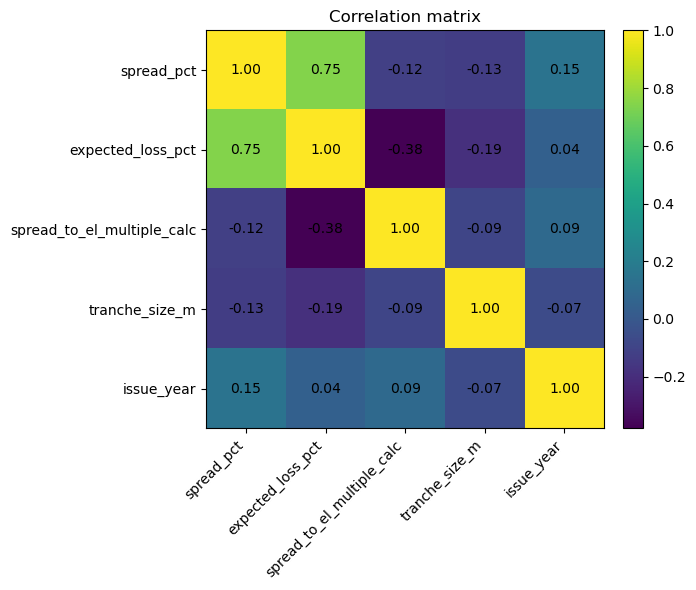

,spread_pct,expected_loss_pct,spread_to_el_multiple_calc,tranche_size_m,issue_year
spread_pct,1.000,0.745,-0.117,-0.127,0.147
expected_loss_pct,0.745,1.000,-0.379,-0.187,0.044
spread_to_el_multiple_calc,-0.117,-0.379,1.000,-0.091,0.091
tranche_size_m,-0.127,-0.187,-0.091,1.000,-0.066
issue_year,0.147,0.044,0.091,-0.066,1.000


In [16]:
corr_vars = ["spread_pct", "expected_loss_pct", "spread_to_el_multiple_calc", "tranche_size_m", "issue_year"]
corr = reg[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr

## Cell 17 — Average spread and expected loss by year
This helps motivate the inclusion of issuance-year controls.

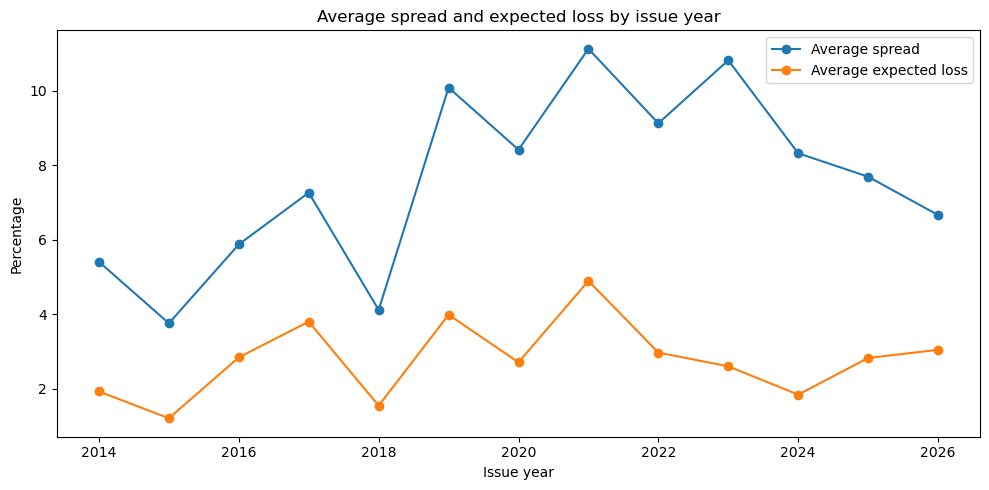

,issue_year,n,avg_spread_pct,avg_expected_loss_pct,median_spread_pct
0,2014,7,5.407,1.926,5.000
1,2015,4,3.756,1.208,3.500
2,2016,9,5.875,2.842,5.000
3,2017,19,7.263,3.801,6.500
4,2018,9,4.117,1.544,2.875
5,2019,3,10.083,3.987,11.250
6,2020,6,8.417,2.709,8.250
7,2021,2,11.125,4.895,11.125
8,2022,4,9.125,2.970,8.625
9,2023,9,10.817,2.602,12.250


In [17]:
year_summary = (
    reg.groupby("issue_year", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           avg_expected_loss_pct=("expected_loss_pct", "mean"),
           median_spread_pct=("spread_pct", "median")
       )
       .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(year_summary["issue_year"], year_summary["avg_spread_pct"], marker="o", label="Average spread")
plt.plot(year_summary["issue_year"], year_summary["avg_expected_loss_pct"], marker="o", label="Average expected loss")
plt.xlabel("Issue year")
plt.ylabel("Percentage")
plt.title("Average spread and expected loss by issue year")
plt.legend()
plt.tight_layout()
plt.show()

year_summary

## Cell 18 — Spread by trigger type
This is a first descriptive check for H2.

<Figure size 1000x500 with 0 Axes>

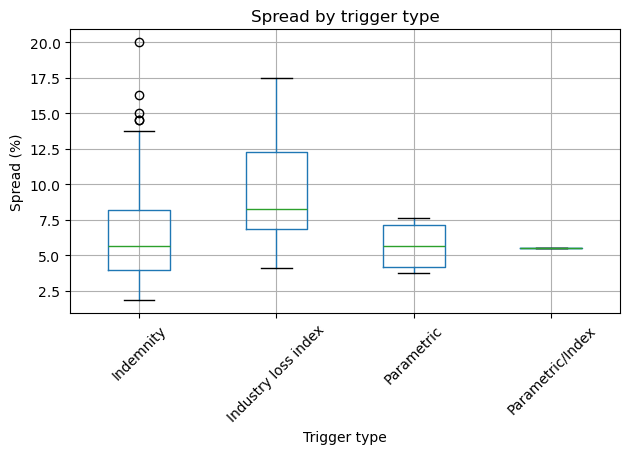

,n,avg_spread_pct,median_spread_pct,avg_expected_loss_pct
trigger_type,,,,
Industry loss index,38,9.089,8.250,4.441
Indemnity,110,6.621,5.688,2.307
Parametric,4,5.681,5.675,2.197
Parametric/Index,1,5.500,5.500,3.220


In [18]:
trigger_summary = (
    reg.groupby("trigger_type", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           median_spread_pct=("spread_pct", "median"),
           avg_expected_loss_pct=("expected_loss_pct", "mean")
       )
       .sort_values("avg_spread_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
reg.boxplot(column="spread_pct", by="trigger_type", rot=45)
plt.suptitle("")
plt.title("Spread by trigger type")
plt.xlabel("Trigger type")
plt.ylabel("Spread (%)")
plt.tight_layout()
plt.show()

trigger_summary

## Cell 19 — Spread by broad peril category
This is a first descriptive check for H3.

<Figure size 1000x500 with 0 Axes>

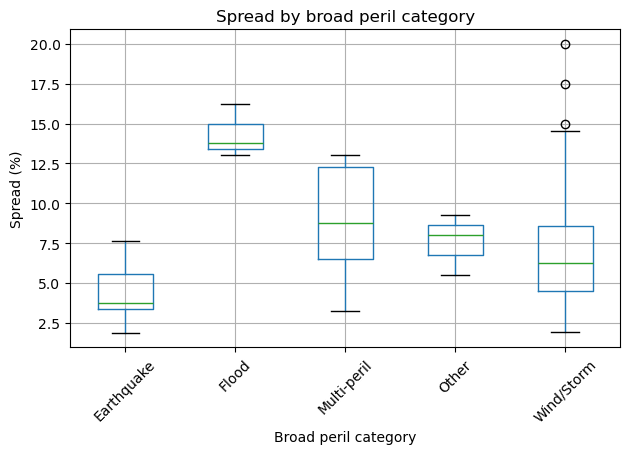

,n,avg_spread_pct,median_spread_pct,avg_expected_loss_pct
broad_peril,,,,
Flood,3,14.333,13.750,5.433
Multi-peril,28,8.705,8.750,3.717
Other,3,7.583,8.000,2.133
Wind/Storm,100,7.084,6.250,2.706
Earthquake,19,4.420,3.750,1.954


In [19]:
peril_summary = (
    reg.groupby("broad_peril", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           median_spread_pct=("spread_pct", "median"),
           avg_expected_loss_pct=("expected_loss_pct", "mean")
       )
       .sort_values("avg_spread_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
reg.boxplot(column="spread_pct", by="broad_peril", rot=45)
plt.suptitle("")
plt.title("Spread by broad peril category")
plt.xlabel("Broad peril category")
plt.ylabel("Spread (%)")
plt.tight_layout()
plt.show()

peril_summary

## Cell 20 — Spread-to-expected-loss multiple
This ratio is useful descriptively because spread normally exceeds expected loss.

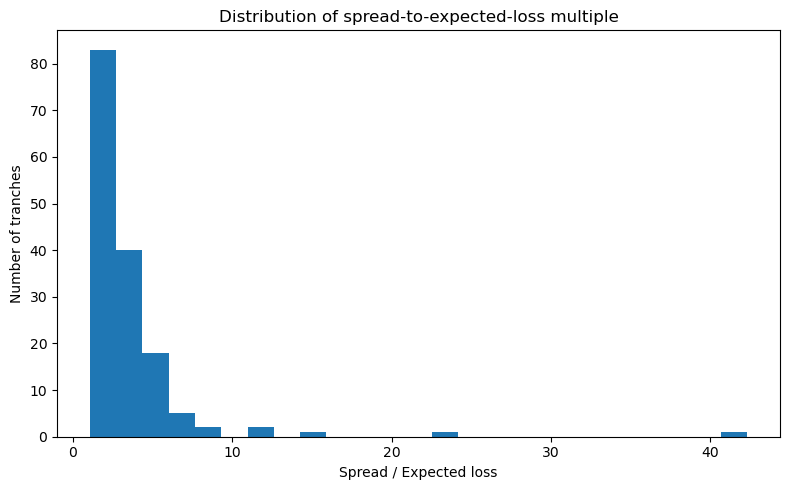

count   153.000
mean      3.623
std       4.099
min       1.066
25%       1.997
50%       2.551
75%       3.893
max      42.308
Name: spread_to_el_multiple_calc, dtype: float64

In [20]:
multiple = reg["spread_to_el_multiple_calc"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8, 5))
plt.hist(multiple, bins=25)
plt.xlabel("Spread / Expected loss")
plt.ylabel("Number of tranches")
plt.title("Distribution of spread-to-expected-loss multiple")
plt.tight_layout()
plt.show()

multiple.describe()

## Cell 21 — Outlier check
These rows are not automatically wrong, but you should inspect them because they can influence regression estimates.

In [21]:
outliers = reg.assign(
    spread_rank=reg["spread_pct"].rank(ascending=False),
    el_rank=reg["expected_loss_pct"].rank(ascending=False),
    multiple_rank=reg["spread_to_el_multiple_calc"].rank(ascending=False)
)

cols = [
    "deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct",
    "spread_to_el_multiple_calc", "trigger_type", "broad_peril", "source_url"
]

print("Highest spreads:")
display(outliers.sort_values("spread_pct", ascending=False)[cols].head(10))

print("Highest expected losses:")
display(outliers.sort_values("expected_loss_pct", ascending=False)[cols].head(10))

print("Highest spread-to-expected-loss multiples:")
display(outliers.sort_values("spread_to_el_multiple_calc", ascending=False)[cols].head(10))

Highest spreads:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
75,Bonanza Re Ltd. (Series 2024-1),Class A,2024,4.090,20.000,4.890,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/bonanza-...
28,Galileo Re Ltd. (Series 2017-1),Class B,2017,9.720,17.500,1.800,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galileo-...
65,FloodSmart Re Ltd. (Series 2023-1),Class A,2023,5.350,16.250,3.037,Indemnity,Flood,https://www.artemis.bm/deal-directory/floodsma...
120,Armor Re II Ltd. (Series 2026-1),Class B,2026,4.220,15.000,3.555,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/armor-re...
53,FloodSmart Re Ltd. (Series 2020-1),Class B,2020,5.680,14.500,2.553,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/floodsma...
50,FloodSmart Re Ltd. (Series 2019-1),Class B,2019,6.010,14.500,2.413,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/floodsma...
61,FloodSmart Re Ltd. (Series 2022-1),Class B,2022,5.480,13.750,2.509,Indemnity,Flood,https://www.artemis.bm/deal-directory/floodsma...
22,Galilei Re Ltd. (Series 2017-1),Class A-2,2017,8.650,13.250,1.532,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
102,Montoya Re Ltd. (Series 2025-2),Class B,2025,7.190,13.125,1.825,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/montoya-...
73,Titania Re Ltd. (Series 2023-1),Class B,2023,3.820,13.000,3.403,Indemnity,Multi-peril,https://www.artemis.bm/deal-directory/titania-...


Highest expected losses:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
28,Galileo Re Ltd. (Series 2017-1),Class B,2017,9.720,17.500,1.800,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galileo-...
15,Galilei Re Ltd. (Series 2016-1),Class A-1,2016,8.650,12.875,1.488,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
22,Galilei Re Ltd. (Series 2017-1),Class A-2,2017,8.650,13.250,1.532,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
98,Meadows Ltd. (Series 2025-1),Class B,2025,7.770,11.500,1.480,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/meadows-...
136,Kilimanjaro III Re Ltd. (Series 2026-2),Class D,2026,7.380,12.250,1.660,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
132,Kilimanjaro III Re Ltd. (Series 2026-1),Class D,2026,7.380,12.250,1.660,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
102,Montoya Re Ltd. (Series 2025-2),Class B,2025,7.190,13.125,1.825,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/montoya-...
130,Kilimanjaro III Re Ltd. (Series 2026-1),Class B,2026,6.970,12.500,1.793,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
134,Kilimanjaro III Re Ltd. (Series 2026-2),Class B,2026,6.970,12.500,1.793,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
97,Meadows Ltd. (Series 2025-1),Class A,2025,6.960,12.250,1.760,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/meadows-...


Highest spread-to-expected-loss multiples:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
125,Buttonwood Re Ltd. (Series 2026-1),Class D,2026,0.130,5.500,42.308,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/buttonwo...
56,Stratosphere Re Ltd. (Series 2020-1),Class A,2020,0.115,2.750,23.913,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/stratosp...
45,Kizuna Re II Ltd. (Series 2018-1),Class A,2018,0.120,1.875,15.625,Indemnity,Earthquake,https://www.artemis.bm/deal-directory/kizuna-r...
156,Winston Re Ltd. (Series 2026-1),Class C,2026,0.490,6.000,12.245,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/winston-...
119,Armor Re II Ltd. (Series 2026-1),Class A,2026,0.440,5.000,11.364,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/armor-re...
71,Residential Reinsurance 2023 Limited (Series 2...,Class 14,2023,0.750,6.500,8.667,Indemnity,Multi-peril,https://www.artemis.bm/deal-directory/resident...
63,Yosemite Re Ltd. (Series 2022-1),Class A,2022,1.160,9.250,7.974,Indemnity,Other,https://www.artemis.bm/deal-directory/yosemite...
74,Bayou Re Ltd. (Series 2024-1),Class A,2024,1.140,8.500,7.456,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/bayou-re...
105,Purple Re Ltd. (Series 2025-1),Class A,2025,1.050,7.250,6.905,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/purple-r...
112,Sanders Re II Ltd. (Series 2025-1),Class A-2,2025,0.622,4.250,6.832,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/sanders-...


# Regression analysis

## Cell 22 — Model 1: simple expected-loss model
This directly tests H1 using a simple OLS specification.

In [22]:
model1 = smf.ols("spread_pct ~ expected_loss_pct", data=reg).fit(cov_type="HC3")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     223.0
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           1.52e-31
Time:                        15:05:57   Log-Likelihood:                -348.22
No. Observations:                 153   AIC:                             700.4
Df Residuals:                     151   BIC:                             706.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4485      0.27

## Cell 23 — Model 2: add trigger and peril controls
This tests whether trigger mechanism and peril category explain spread differences beyond expected loss.

In [23]:
model2 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril)",
    data=reg
).fit(cov_type="HC3")

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     50.65
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           3.82e-38
Time:                        15:05:57   Log-Likelihood:                -335.09
No. Observations:                 153   AIC:                             688.2
Df Residuals:                     144   BIC:                             715.5
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

## Cell 24 — Model 3: full model with issuance-year controls
This matches the paper’s main regression logic: expected loss + trigger + peril + issuance year.

In [24]:
model3 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit(cov_type="HC3")

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     42.95
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           5.87e-48
Time:                        15:05:57   Log-Likelihood:                -299.77
No. Observations:                 153   AIC:                             641.5
Df Residuals:                     132   BIC:                             705.2
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [25]:
model1 = smf.ols(
    "spread_pct ~ expected_loss_pct",
    data=reg
).fit(cov_type="HC3")

model2 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type)",
    data=reg
).fit(cov_type="HC3")

model3 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril)",
    data=reg
).fit(cov_type="HC3")

model4 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit(cov_type="HC3")

In [26]:
# Print full regression outputs
print(model1.summary())
print(model2.summary())
print(model3.summary())
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     223.0
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           1.52e-31
Time:                        15:05:57   Log-Likelihood:                -348.22
No. Observations:                 153   AIC:                             700.4
Df Residuals:                     151   BIC:                             706.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4485      0.27

# Nonlinear models

In [27]:
from sklearn.linear_model import LinearRegression

# NOTE: mlr_model is defined after the preprocessor is built (see below).


In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
def calculate_rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_RMSE": calculate_rmse(y_train, y_train_pred),
        "test_RMSE": calculate_rmse(y_test, y_test_pred),
        "train_MAE": mean_absolute_error(y_train, y_train_pred),
        "test_MAE": mean_absolute_error(y_test, y_test_pred),
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred)
    }

In [30]:
base_data = reg.copy()

features = [
    "expected_loss_pct",
    "trigger_type",
    "broad_peril",
    "issue_year"
]

target = "spread_pct"

model_data = base_data[features + [target]].dropna().copy()

X = model_data[features]
y = model_data[target]

numeric_features = ["expected_loss_pct", "issue_year"]
categorical_features = ["trigger_type", "broad_peril"]

print("Sample size:", len(model_data))
display(model_data.head())

Sample size: 153


,expected_loss_pct,trigger_type,broad_peril,issue_year,spread_pct
0,2.840,Indemnity,Wind/Storm,2014,6.350
1,1.280,Indemnity,Wind/Storm,2014,4.250
2,2.200,Indemnity,Multi-peril,2014,6.750
3,1.140,Indemnity,Multi-peril,2014,5.000
4,2.200,Indemnity,Multi-peril,2014,7.000


> **Note — single-split use:** The train/test split below is used **only** to supply `X_train`/`y_train` for Optuna hyperparameter tuning. Final model comparison uses k-fold cross-validation on the full sample (see the CV comparison cell below). The held-out test set is retained as a secondary robustness check.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 114
Test observations: 39


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", make_onehot_encoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [33]:
# mlr_model defined here, after preprocessor is available
mlr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

mlr_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [34]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
n_trials = 40

In [35]:
def objective_random_forest(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [36]:
def objective_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [37]:
def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "loss_function": "RMSE",
        "verbose": False,
        "random_seed": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [38]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_random_forest, n_trials=n_trials)

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgboost, n_trials=n_trials)

study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_catboost, n_trials=n_trials)

print("Best RF CV RMSE:", study_rf.best_value)
print("Best RF params:", study_rf.best_params)

print("\nBest XGBoost CV RMSE:", study_xgb.best_value)
print("Best XGBoost params:", study_xgb.best_params)

print("\nBest CatBoost CV RMSE:", study_cat.best_value)
print("Best CatBoost params:", study_cat.best_params)

Best RF CV RMSE: 2.312914463783114
Best RF params: {'n_estimators': 395, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None}

Best XGBoost CV RMSE: 2.1772345731201925
Best XGBoost params: {'n_estimators': 498, 'max_depth': 4, 'learning_rate': 0.0361179317208496, 'subsample': 0.6316743760351339, 'colsample_bytree': 0.6369451844134355, 'min_child_weight': 2.9194918298697825, 'reg_alpha': 4.627328261420112, 'reg_lambda': 0.6496380084960077}

Best CatBoost CV RMSE: 2.069258770943416
Best CatBoost params: {'iterations': 546, 'depth': 4, 'learning_rate': 0.14546694360993317, 'l2_leaf_reg': 13.379070320152314, 'random_strength': 4.316913950035778, 'bagging_temperature': 2.3659185262709124}


In [39]:
best_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
    ))
])

best_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study_xgb.best_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

best_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        **study_cat.best_params,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    ))
])

best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_cat.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Cross-validated model comparison (primary Table III)

This cell computes 5-fold cross-validated RMSE, MAE, and R² for all four models using the best hyperparameters found by Optuna. Cross-validating on the full sample (`X`, `y`) gives a more reliable and comparable picture than a single held-out split.

**Methodological caveat:** the tree hyperparameters were tuned on `X_train` (a subset), then evaluated on all folds of the full data — a mild source of optimism. For a fully clean estimate you would use nested CV (tune inside each outer fold); that is noted as a limitation rather than implemented here, as it is standard practice for course-level work of this scope.

In [40]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LinearRegression

# Rebuild pipelines with tuned params (do NOT re-tune; just use Optuna best params)
cv_mlr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

cv_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **study_rf.best_params,
        random_state=42, n_jobs=-1
    ))
])

cv_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study_xgb.best_params,
        objective="reg:squarederror",
        random_state=42, n_jobs=-1
    ))
])

cv_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        **study_cat.best_params,
        loss_function="RMSE",
        verbose=False, random_seed=42
    ))
])

# 5-fold CV on the full dataset
cv_full = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]

model_cv_specs = {
    "Multiple linear regression": cv_mlr,
    "Random Forest":              cv_rf,
    "XGBoost":                    cv_xgb,
    "CatBoost":                   cv_cat,
}

cv_rows = []
for name, pipe in model_cv_specs.items():
    res = cross_validate(pipe, X, y, cv=cv_full, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model":       name,
        "CV RMSE (mean)": (-res["test_neg_root_mean_squared_error"]).mean(),
        "CV RMSE (std)":  (-res["test_neg_root_mean_squared_error"]).std(),
        "CV MAE (mean)":  (-res["test_neg_mean_absolute_error"]).mean(),
        "CV MAE (std)":   (-res["test_neg_mean_absolute_error"]).std(),
        "CV R² (mean)":   res["test_r2"].mean(),
        "CV R² (std)":    res["test_r2"].std(),
    })

cv_comparison = pd.DataFrame(cv_rows).sort_values("CV RMSE (mean)").reset_index(drop=True)
print("PRIMARY TABLE III — 5-fold cross-validated model comparison (full sample)")
display(cv_comparison)


PRIMARY TABLE III — 5-fold cross-validated model comparison (full sample)


,Model,CV RMSE (mean),CV RMSE (std),CV MAE (mean),CV MAE (std),CV R² (mean),CV R² (std)
0,CatBoost,1.879,0.387,1.328,0.240,0.686,0.103
1,XGBoost,1.914,0.449,1.395,0.297,0.677,0.110
2,Random Forest,2.132,0.371,1.619,0.255,0.595,0.113
3,Multiple linear regression,2.330,0.323,1.717,0.174,0.511,0.139


## Single-split robustness check (secondary)

The table below evaluates each tuned model on the single held-out test set (25 % of the data, `random_state=42`). This is reported as a **secondary robustness check** only — the primary comparison is the cross-validated table above. Results from a single split are sensitive to which observations land in the test set and should not be over-interpreted.

In [41]:
test_comparison = pd.DataFrame([
    evaluate_model("Multiple linear regression", mlr_model, X_train, X_test, y_train, y_test),
    evaluate_model("Random Forest", best_rf, X_train, X_test, y_train, y_test),
    evaluate_model("XGBoost", best_xgb, X_train, X_test, y_train, y_test),
    evaluate_model("CatBoost", best_cat, X_train, X_test, y_train, y_test)
])

test_comparison = test_comparison.sort_values("test_RMSE").reset_index(drop=True)

display(test_comparison)

,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2
0,XGBoost,1.259,1.718,0.856,1.268,0.878,0.734
1,CatBoost,0.799,1.945,0.524,1.380,0.951,0.659
2,Random Forest,1.610,2.137,1.140,1.519,0.800,0.588
3,Multiple linear regression,2.139,2.331,1.499,1.739,0.646,0.510


In [42]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
def get_transformed_data(fitted_pipeline, X):
    """
    Applies the fitted preprocessing step and returns a dataframe
    with readable feature names.
    """
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    X_transformed = fitted_preprocessor.transform(X)

    return pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )


def calculate_tree_shap(fitted_pipeline, X):
    """
    Calculates SHAP values for a fitted tree-based pipeline.
    """
    X_transformed = get_transformed_data(fitted_pipeline, X)
    fitted_model = fitted_pipeline.named_steps["model"]

    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_transformed)

    shap_importance = pd.DataFrame({
        "feature": X_transformed.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    return shap_importance, shap_values, X_transformed

In [44]:
tree_models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "CatBoost": best_cat
}

shap_outputs = {}

for model_name, model in tree_models.items():
    importance, shap_values, X_test_transformed = calculate_tree_shap(model, X_test)

    shap_outputs[model_name] = {
        "importance": importance,
        "shap_values": shap_values,
        "X_test_transformed": X_test_transformed
    }

    print(model_name)
    display(importance.head(15))
    

Random Forest


,feature,mean_abs_shap
9,num__expected_loss_pct,2.730
10,num__issue_year,0.469
4,cat__broad_peril_Earthquake,0.092
6,cat__broad_peril_Multi-peril,0.082
0,cat__trigger_type_Indemnity,0.056
8,cat__broad_peril_Wind/Storm,0.043
1,cat__trigger_type_Industry loss index,0.021
5,cat__broad_peril_Flood,0.002
7,cat__broad_peril_Other,0.001
2,cat__trigger_type_Parametric,0.000


XGBoost


,feature,mean_abs_shap
9,num__expected_loss_pct,2.666
10,num__issue_year,1.139
8,cat__broad_peril_Wind/Storm,0.202
4,cat__broad_peril_Earthquake,0.188
0,cat__trigger_type_Indemnity,0.157
1,cat__trigger_type_Industry loss index,0.127
6,cat__broad_peril_Multi-peril,0.090
7,cat__broad_peril_Other,0.019
5,cat__broad_peril_Flood,0.006
2,cat__trigger_type_Parametric,0.000


CatBoost


,feature,mean_abs_shap
9,num__expected_loss_pct,2.750
10,num__issue_year,1.063
4,cat__broad_peril_Earthquake,0.241
8,cat__broad_peril_Wind/Storm,0.119
0,cat__trigger_type_Indemnity,0.092
6,cat__broad_peril_Multi-peril,0.074
1,cat__trigger_type_Industry loss index,0.050
5,cat__broad_peril_Flood,0.025
7,cat__broad_peril_Other,0.024
3,cat__trigger_type_Parametric/Index,0.021


Random Forest


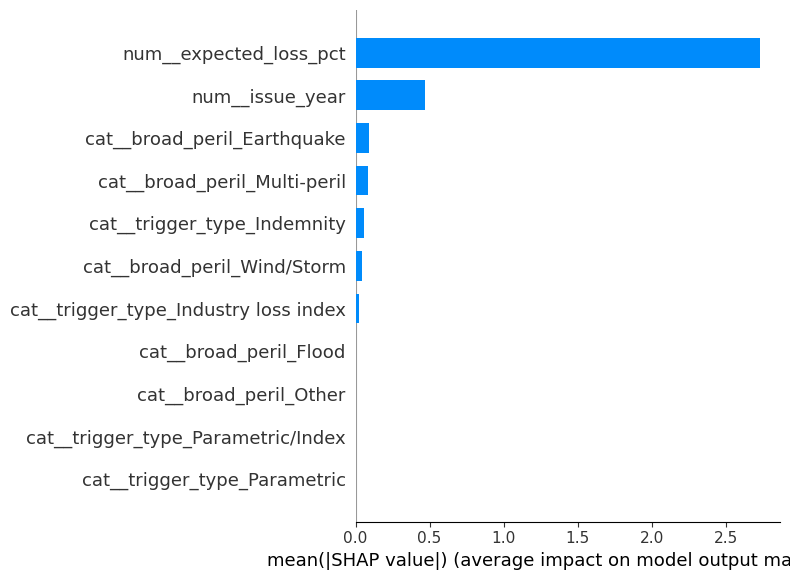

XGBoost


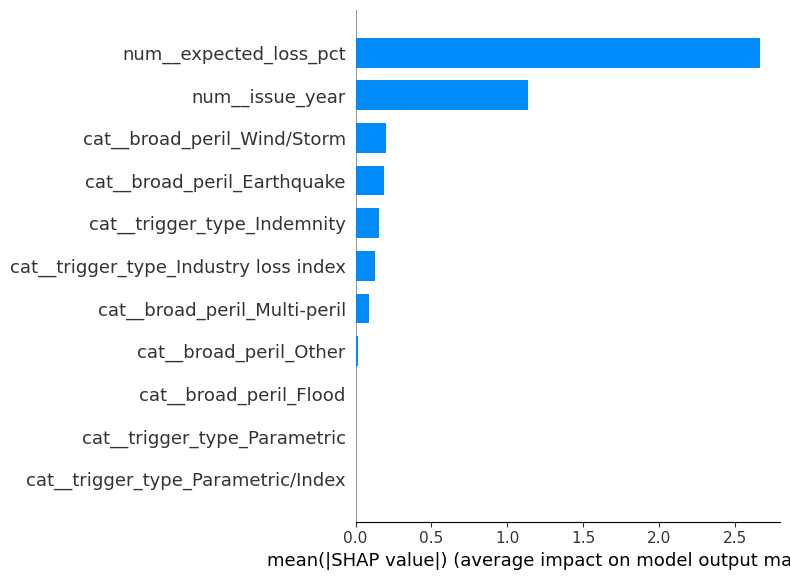

CatBoost


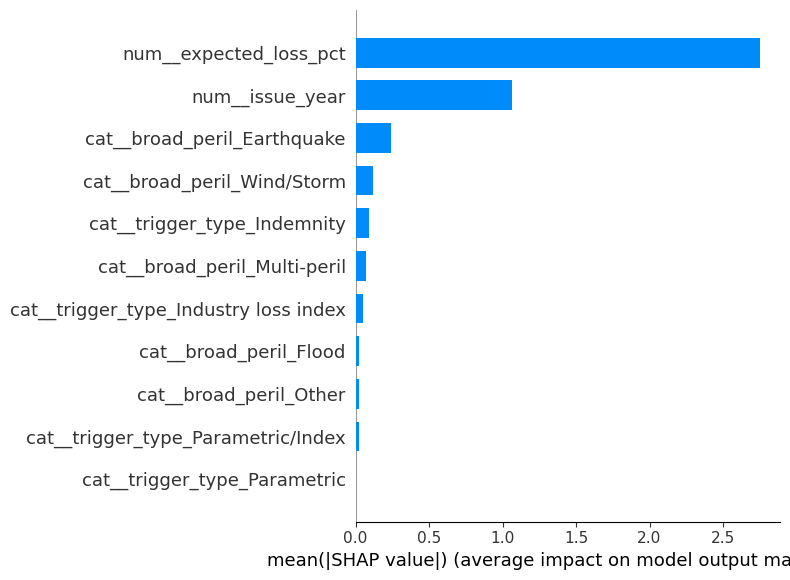

In [45]:
for model_name in tree_models.keys():
    print(model_name)

    shap.summary_plot(
        shap_outputs[model_name]["shap_values"],
        shap_outputs[model_name]["X_test_transformed"],
        plot_type="bar",
        max_display=15
    )

Random Forest


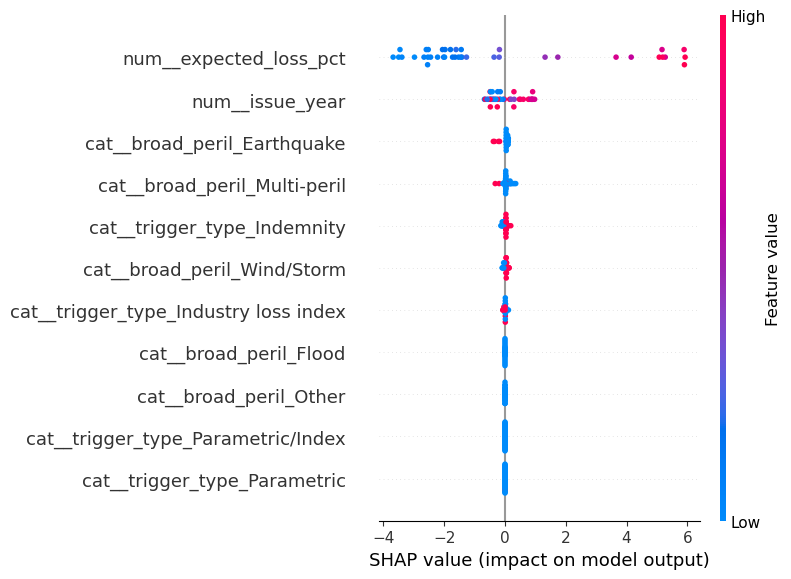

XGBoost


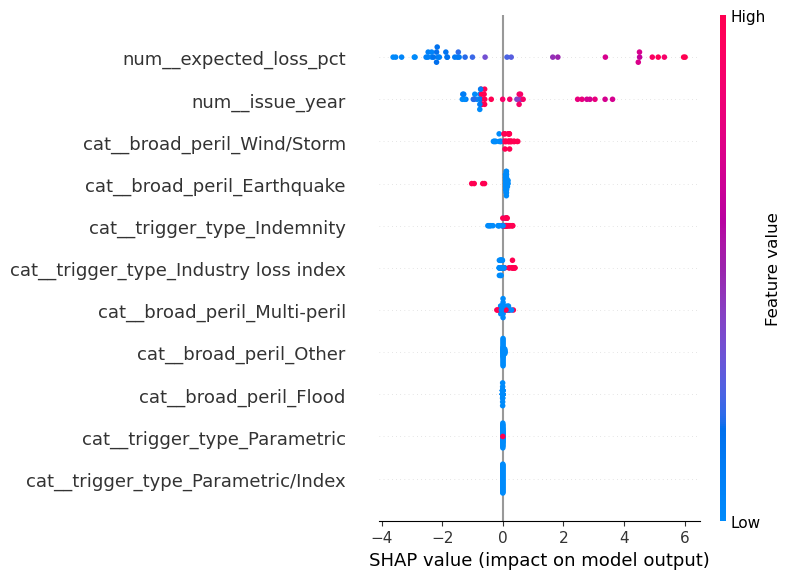

CatBoost


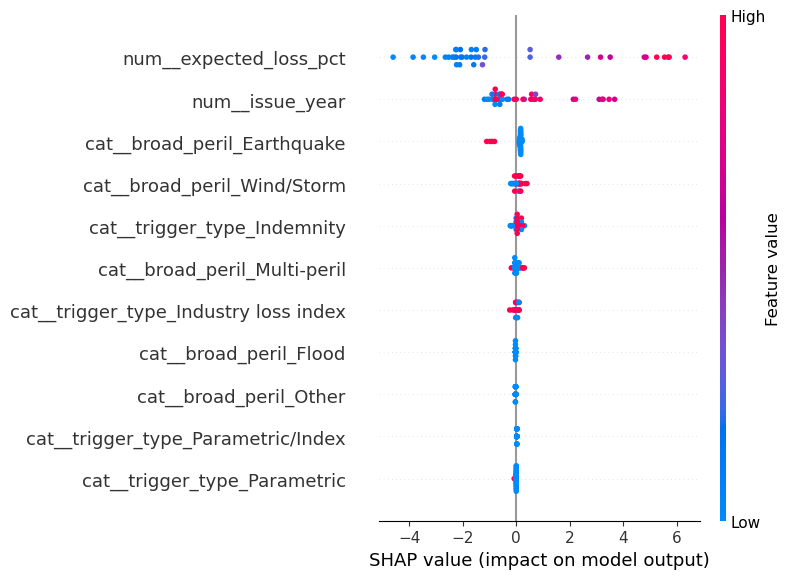

In [46]:
for model_name in tree_models.keys():
    print(model_name)

    shap.summary_plot(
        shap_outputs[model_name]["shap_values"],
        shap_outputs[model_name]["X_test_transformed"],
        max_display=15
    )

In [47]:
def group_feature_name(feature):
    if "expected_loss_pct" in feature:
        return "expected_loss_pct"
    elif "issue_year" in feature:
        return "issue_year"
    elif "trigger_type" in feature:
        return "trigger_type"
    elif "broad_peril" in feature:
        return "broad_peril"
    else:
        return feature


grouped_shap_list = []

for model_name in tree_models.keys():
    temp = shap_outputs[model_name]["importance"].copy()
    temp["feature_group"] = temp["feature"].apply(group_feature_name)

    grouped = (
        temp
        .groupby("feature_group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )

    grouped["model"] = model_name
    grouped_shap_list.append(grouped)

grouped_shap_importance = pd.concat(grouped_shap_list, ignore_index=True)

display(grouped_shap_importance)

,feature_group,mean_abs_shap,model
0,expected_loss_pct,2.730,Random Forest
1,issue_year,0.469,Random Forest
2,broad_peril,0.220,Random Forest
3,trigger_type,0.077,Random Forest
4,expected_loss_pct,2.666,XGBoost
5,issue_year,1.139,XGBoost
6,broad_peril,0.505,XGBoost
7,trigger_type,0.284,XGBoost
8,expected_loss_pct,2.750,CatBoost
9,issue_year,1.063,CatBoost


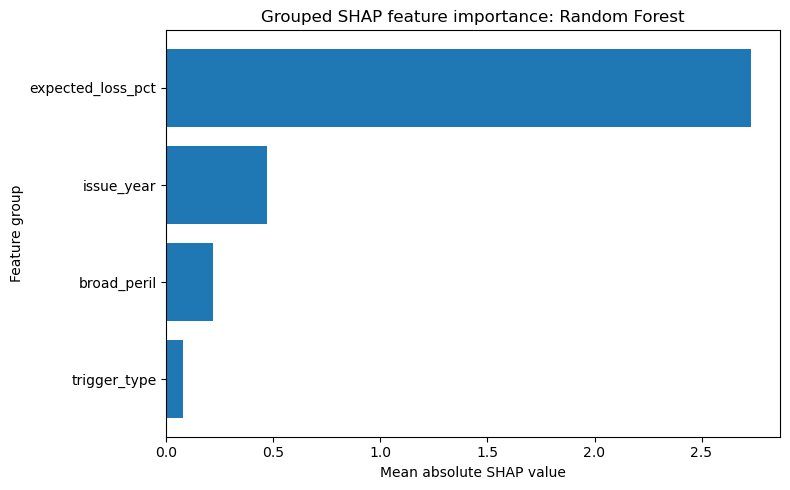

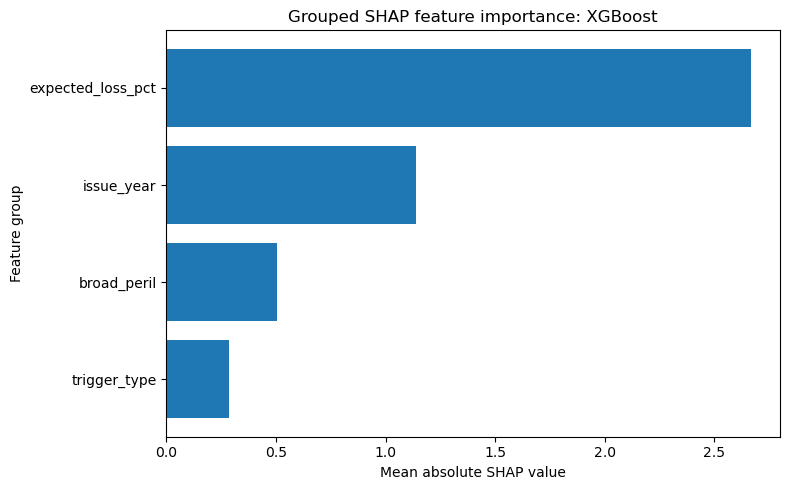

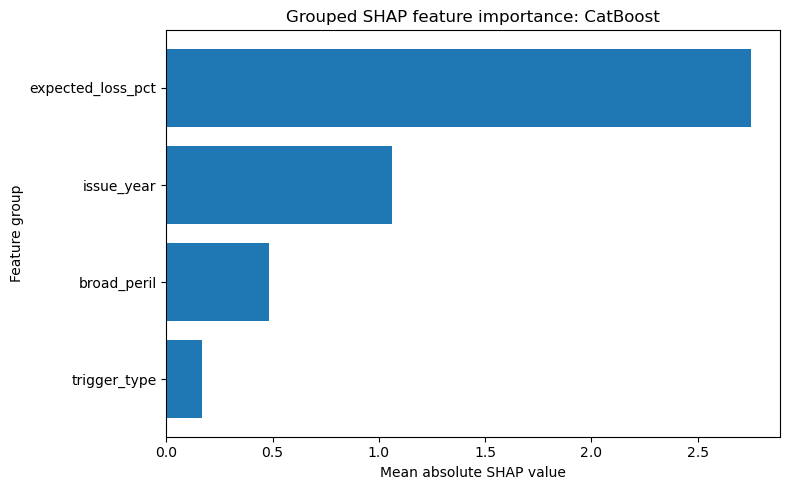

In [48]:
for model_name in ["Random Forest", "XGBoost", "CatBoost"]:
    plot_data = (
        grouped_shap_importance[
            grouped_shap_importance["model"] == model_name
        ]
        .sort_values("mean_abs_shap", ascending=True)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(
        plot_data["feature_group"],
        plot_data["mean_abs_shap"]
    )
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature group")
    plt.title(f"Grouped SHAP feature importance: {model_name}")
    plt.tight_layout()
    plt.show()

## Cell 26 — Model comparison table
Use this table in the Results section to compare explanatory power across specifications.

In [49]:
model_comparison = pd.DataFrame({
    "Model": ["M1: EL only", "M2: + trigger", "M3: + peril", "M4: + year FE"],
    "Dependent variable": ["spread_pct", "spread_pct", "spread_pct", "spread_pct"],
    "N": [int(m.nobs) for m in [model1, model2, model3, model4]],
    "R_squared": [m.rsquared for m in [model1, model2, model3, model4]],
    "Adj_R_squared": [m.rsquared_adj for m in [model1, model2, model3, model4]],
    "AIC": [m.aic for m in [model1, model2, model3, model4]],
    "BIC": [m.bic for m in [model1, model2, model3, model4]],
})

model_comparison


,Model,Dependent variable,N,R_squared,Adj_R_squared,AIC,BIC
0,M1: EL only,spread_pct,153,0.555,0.552,700.447,706.508
1,M2: + trigger,spread_pct,153,0.561,0.549,704.413,719.565
2,M3: + peril,spread_pct,153,0.625,0.604,688.187,715.461
3,M4: + year FE,spread_pct,153,0.764,0.728,641.533,705.172


## Cell 27 — Extract key coefficients for interpretation
This table is easier to interpret than the full statsmodels output.

In [50]:
def tidy_model(model, model_name):
    result = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_error": model.bse.values,
        "p_value": model.pvalues.values,
        "ci_low": model.conf_int()[0].values,
        "ci_high": model.conf_int()[1].values,
    })
    result.insert(0, "model", model_name)
    return result

tidy_results = pd.concat([
    tidy_model(model1, "M1"),
    tidy_model(model2, "M2"),
    tidy_model(model3, "M3"),
    tidy_model(model4, "M4")
], ignore_index=True)

# Show the most important expected-loss coefficient across models.
tidy_results[tidy_results["term"].isin(["expected_loss_pct", "log_expected_loss"])]

,model,term,coef,std_error,p_value,ci_low,ci_high
1,M1,expected_loss_pct,1.322,0.089,0.000,1.148,1.495
6,M2,expected_loss_pct,1.364,0.124,0.000,1.121,1.608
15,M3,expected_loss_pct,1.274,0.133,0.000,1.014,1.534
36,M4,expected_loss_pct,1.363,0.126,0.000,1.116,1.610


## Cell 28 — Residual diagnostics for the main model
These plots help assess whether the linear model is reasonable.

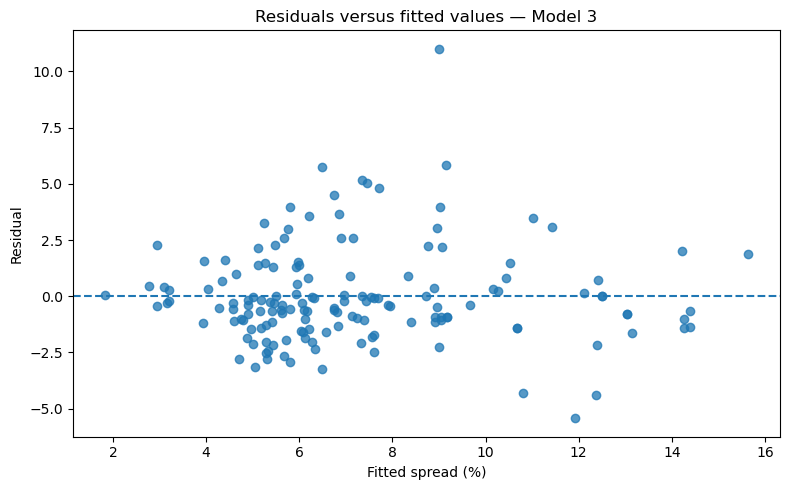

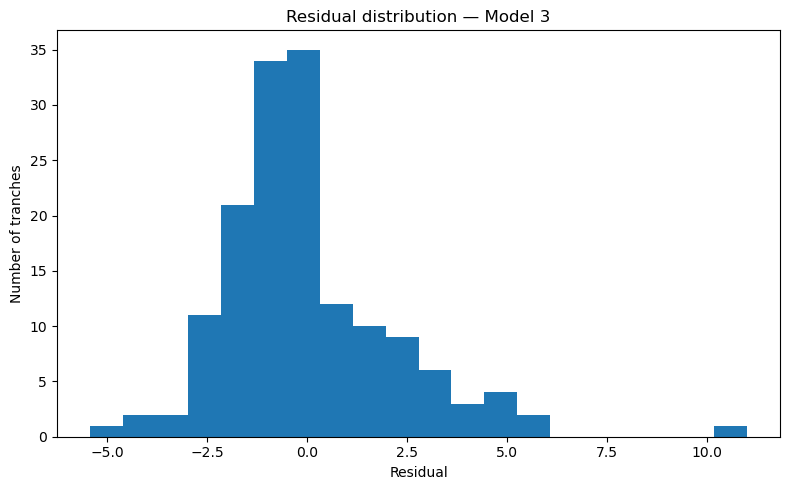

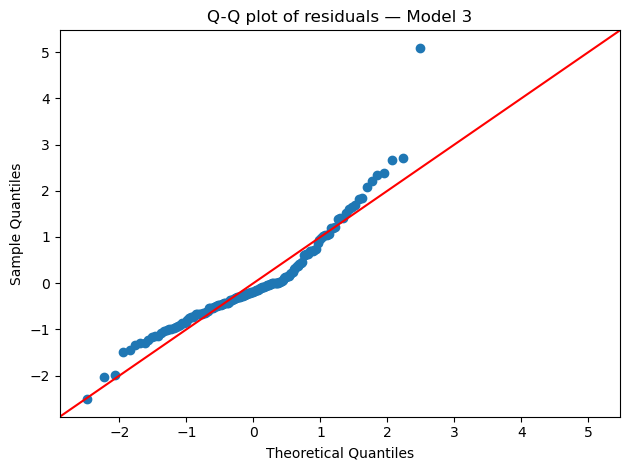

In [51]:
main_model = model3
fitted = main_model.fittedvalues
resid = main_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted spread (%)")
plt.ylabel("Residual")
plt.title("Residuals versus fitted values — Model 3")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=20)
plt.xlabel("Residual")
plt.ylabel("Number of tranches")
plt.title("Residual distribution — Model 3")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q plot of residuals — Model 3")
plt.tight_layout()
plt.show()

## Cell 29 — Influence check
Cook’s distance identifies observations that may strongly affect the regression.

In [52]:
# Influence diagnostics require the non-robust fitted model object.
model3_nonrobust = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit()

influence = model3_nonrobust.get_influence()
reg_influence = reg.copy()
reg_influence["cooks_distance"] = influence.cooks_distance[0]

threshold = 4 / len(reg_influence)
print(f"Common Cook's distance threshold: {threshold:.4f}")

influential = reg_influence.sort_values("cooks_distance", ascending=False)[[
    "deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct",
    "trigger_type", "broad_peril", "cooks_distance", "source_url"
]].head(10)

influential

Common Cook's distance threshold: 0.0261


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,trigger_type,broad_peril,cooks_distance,source_url
60,Black Kite Re Limited (Series 2022-1),Class A,2022,3.220,5.500,Parametric/Index,Other,1.621,https://www.artemis.bm/deal-directory/black-ki...
75,Bonanza Re Ltd. (Series 2024-1),Class A,2024,4.090,20.000,Indemnity,Wind/Storm,0.213,https://www.artemis.bm/deal-directory/bonanza-...
48,Alamo Re Ltd. (Series 2019-1),Class A,2019,1.800,4.500,Indemnity,Wind/Storm,0.077,https://www.artemis.bm/deal-directory/alamo-re...
76,Bonanza Re Ltd. (Series 2024-1),Class B,2024,0.760,3.750,Indemnity,Wind/Storm,0.042,https://www.artemis.bm/deal-directory/bonanza-...
64,Acorn Re Ltd. (Series 2023-1),Class A,2023,0.910,4.350,Parametric,Earthquake,0.038,https://www.artemis.bm/deal-directory/acorn-re...
77,Bonanza Re Ltd. (Series 2024-1),Class C,2024,1.820,5.500,Indemnity,Wind/Storm,0.035,https://www.artemis.bm/deal-directory/bonanza-...
63,Yosemite Re Ltd. (Series 2022-1),Class A,2022,1.160,9.250,Indemnity,Other,0.034,https://www.artemis.bm/deal-directory/yosemite...
62,Northshore Re II Ltd. (Series 2022-1),Class A,2022,2.020,8.000,Industry loss index,Other,0.034,https://www.artemis.bm/deal-directory/northsho...
50,FloodSmart Re Ltd. (Series 2019-1),Class B,2019,6.010,14.500,Indemnity,Wind/Storm,0.031,https://www.artemis.bm/deal-directory/floodsma...
143,Residential Reinsurance 2026 Limited (Series 2...,Class 14,2026,6.100,6.500,Indemnity,Multi-peril,0.026,https://www.artemis.bm/deal-directory/resident...


## Cell 30 — Save cleaned analysis outputs
This creates CSV files you can use in your appendix or for reproducibility.

In [53]:
output_dir = Path(".")

reg.to_csv(output_dir / "catbond_regression_sample_clean.csv", index=False)
year_summary.to_csv(output_dir / "catbond_year_summary.csv", index=False)
trigger_summary.to_csv(output_dir / "catbond_trigger_summary.csv")
peril_summary.to_csv(output_dir / "catbond_peril_summary.csv")
model_comparison.to_csv(output_dir / "catbond_model_comparison.csv", index=False)
tidy_results.to_csv(output_dir / "catbond_regression_coefficients.csv", index=False)

print("Saved cleaned datasets and summary tables as CSV files.")

Saved cleaned datasets and summary tables as CSV files.


# Suggested interpretation notes

Use the EDA and regression output to answer the hypotheses:

- **H1:** supported if `expected_loss_pct` has a positive and statistically meaningful coefficient.
- **H2:** supported if trigger-type dummy variables are jointly or individually meaningful after controlling for expected loss.
- **H3:** supported if broad peril categories differ after controlling for expected loss.
- **H4:** supported if issuance-year fixed effects add explanatory power or if year dummies show meaningful differences.

Be careful: this is an observational, manually constructed sample. Interpret coefficients as associations, not causal effects.